
<div align="center">
  <hr>
  <h1><strong>🧠 Predicción de Supervivencia del Titanic con Perceptrón </strong></h1>

  <hr>
</div>

### 📌 Descripción del proyecto

Este proyecto implementa un perceptrón simple desde cero (usando la clase Perceptron del módulo rna) para resolver un problema clásico de clasificación: predecir la supervivencia de los pasajeros del Titanic, basado en datos reales.

Se aplican técnicas de preprocesamiento de datos (limpieza, imputación de valores nulos, codificación de variables categóricas y escalado de características) y se entrena el modelo utilizando descenso de gradiente.

### 📦 El Repositorio
El repositorio para aprendizaje de redes neuronales está disponible de forma  pública en https://github.com/RNA-UNIV/rna

El objetivo del repositorio es el de proveer funciones y clases con implementaciones básicas de algoritmos de redes neuronales, carga de datasets, carga de modelos y carga de ejemplos para pruebas y visualizciones.

Se instala directamente desde el repositorio mediante **!pip install https://github.com/RNA-UNIV/rna/archive/refs/heads/main.zip**. Esta instalación descarga los archivos python para trabajar y prepara las estructuras de carpetas para realizar descargas de recursos (datasets, modelos, archivos, etc.) bajo demanda.
  
## 🎯 Objetivo
Este notebook demuestra el uso del repositorio `rna` para:

- 📚 **Cargar dataset**
- 📊 **Visualizar información** en formato JSON, árbol y tablas
- 🧠 **Implementar un perceptrón** para predecir supervivencia en el titanic

## 📚 Contenido
- 🗃️ Instalación del Paquete
- 📥 Carga de dataset
- 🔍 Exploración de información
- 📊 Uso con NumPy y Pandas
- 🤖 Ejemplo de con neurona lineal

## 🗃️ Instalación del Paquete

In [1]:
!pip install https://github.com/RNA-UNIV/rna/archive/refs/heads/main.zip
# Forzar insatalación:
# !pip install https://github.com/RNA-UNIV/rna/archive/refs/heads/main.zip --upgrade

  Using cached https://github.com/RNA-UNIV/rna/archive/refs/heads/main.zip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# 📥 Carga de Dataset con DataLoader

La clase `DataLoader` permite administrar datasets, modelos y recursos descargados automáticamente.

## 🔧 Funciones principales
1. 🔍 Consultar información.
2. 📊 Cargar como NumPy.
3. 🐼 Cargar como DataFrame.

En el repositorio Git de datasets, cada conjunto de datos cuenta con su propia carpeta, nombrada según el dataset. En su interior se encuentran el archivo de datos (en formato .csv o .zip), un documento Markdown con la documentación detallada y un archivo de metadatos (info.json). Estos archivos se descargan localmente bajo demanda, organizándose en una subcarpeta con el mismo nombre del dataset.

# 🚀 Ejemplos de Uso

> 💡 **Recomendación**
>
> Ejecute las celdas secuencialmente para comprender el flujo completo de trabajo.

## 🔍 Información del Dataset **Titanic**
`dataset_info` retorna la información en formato **json** mientras que `dataset_info_display` muestra la información en formato mas legible, ej: arbol

In [2]:
from rna.data import DataLoader

# Usar método dataset_info para recuperar json con la información
DataLoader.dataset_info_display('titanic')

<IPython.core.display.JSON object>

## 🚢 Carga del dataset **Titanic** como arreglo NumPy

In [3]:
from pandas import DataFrame
from IPython.display import display
(cols, data) = DataLoader.load_array('titanic')

# convierte a DataFrame para mejor visualización
df = DataFrame(data, columns=cols)
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0,C148,C


## 🚢 Carga de dataset **Titanic** como DataFrame Pandas

In [4]:
df = DataLoader.load_dataframe('titanic')

display(df.head(5))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🛟 Predicción de Supervivencia

Esta sección desarrolla un ejemplo completo de entrenamiento y evaluación de un perceptrón para la predicción de supervivencia de los pasajeros del Titanic.

El proceso comienza con la carga del conjunto de datos, seguido de una etapa de limpieza y preparación: los **valores faltantes** de la edad se imputan con la media, mientras que los del puerto de embarque **se completan** con la moda. La variable 'Sex' se transforma a valores numéricos (0 para masculino, 1 para femenino) y 'Embarked' se convierte en variables dummy mediante one-hot encoding.

Luego se seleccionan las características relevantes: clase, edad, número de hermanos o cónyuges, tarifa, sexo y las tres categorías del puerto de embarque. Estas variables se escalan con **StandardScaler** para optimizar el rendimiento del modelo. Finalmente, se crea una instancia del **perceptrón** configurada y salida detallada, y se entrena con los datos procesados para predecir la supervivencia.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from rna.ClassNeuronaLineal import NeuronaLineal
from IPython.display import display
from rna.data import DataLoader
from rna.ClassPerceptron import Perceptron
from sklearn.preprocessing import StandardScaler

# Cargar el DataFrame de titanic
df = DataLoader.load_dataframe('titanic')

# Llenar la edad con el valor promedio (media)
edad_promedio = df['Age'].mean()
df['Age'] = df['Age'].fillna(edad_promedio)

# Llenar 'Embarked' si hay algún nulo (usamos la moda, que es 'S')
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Numerizar 'Sex': male = 0, female = 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-Hot Encoding para 'Embarked' (crea columnas: Embarked_C, Embarked_Q, Embarked_S)
df = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked')


# SELECCIÓN DE CARACTERÍSTICAS Y VARIABLE OBJETIVO
feature_columns = ['Pclass', 'Age', 'SibSp', 'Fare', 'Sex', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

x_data = df[feature_columns]

print("✅ Primeras filas de los datos procesados:")
display(x_data.head())

# Variable objetivo (y) - sobrevivio
y_data = df['Survived']


# Escalar las características de entrada
data_scaler = StandardScaler()
X_scaled = data_scaler.fit_transform(x_data)

# Crear y entrenar el modelo
modelo = Perceptron(epochs=1000, alpha=0.01, verbose=1)
modelo.fit(X_scaled, y_data);

✅ Primeras filas de los datos procesados:


,Pclass,Age,SibSp,Fare,Sex,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,7.2500,0,False,False,True
1,1,38.0,1,71.2833,1,True,False,False
2,3,26.0,0,7.9250,1,False,False,True
3,1,35.0,1,53.1000,1,False,False,True
4,3,35.0,0,8.0500,0,False,False,True


Época 1000/1000 - 100.0% |██████████████████████████████| accuracy: 0.754209


## 📈 Evaluación y Resultados
Se evalua el rendimiento del modelo mediante un análisis visual y cuantitativo.

Se generan tres gráficos: la **evolución del error** durante el entrenamiento para verificar la convergencia del modelo, una **matriz de confusión** con porcentajes para visualizar aciertos y errores por clase, y un gráfico de barras **comparativo** entre los valores **reales** y los **predichos**.

Complementariamente, se calculan **métricas** como accuracy, precision, recall y F1-score, junto con un análisis de la matriz de confusión y un reporte de clasificación.

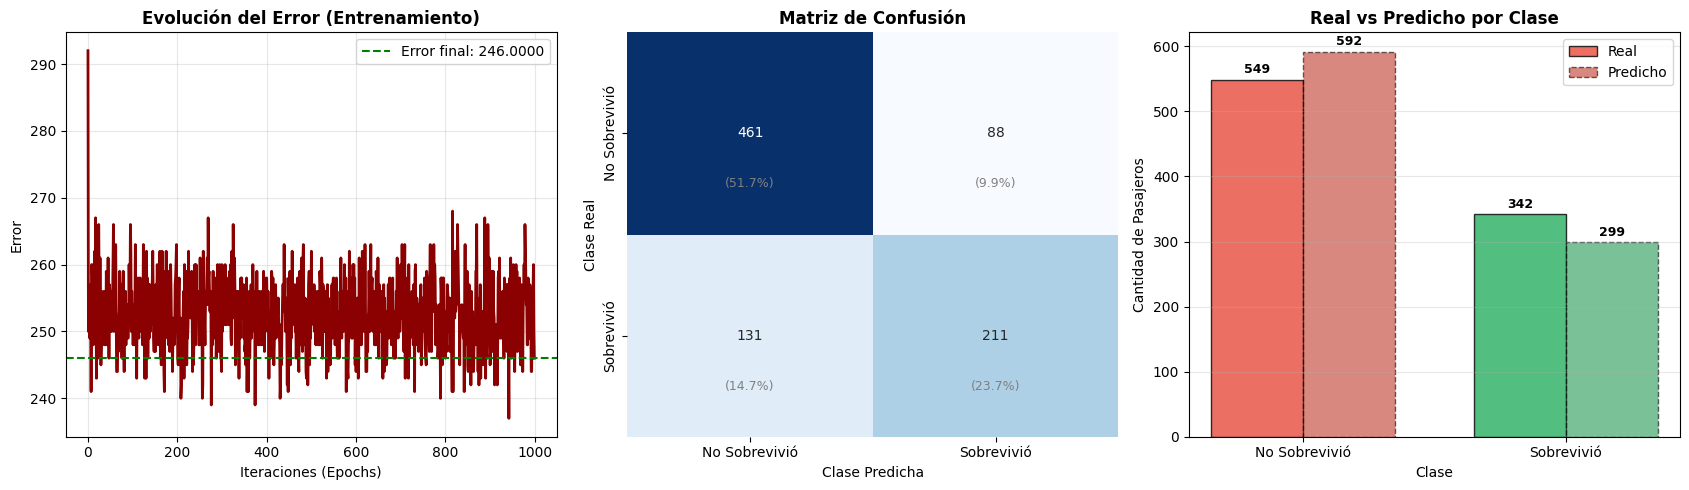


📊 ESTADÍSTICAS DEL ENTRENAMIENTO:
  • Error inicial (Epoch 0): 292.000000
  • Error final............: 246.000000
  • Reducción..............: 46.000000
  • Mejora.................: 15.8%

🎯 MÉTRICAS DE CLASIFICACIÓN:
  • Accuracy  (Precisión global)....: 0.7542 (75.42%)
  • Precision (Calidad predicción)...: 0.7057
  • Recall    (Sensibilidad).........: 0.6170
  • F1-Score  (Balance P-R)..........: 0.6583

🧮 ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:
  • Verdaderos Negativos  (correctamente predichos como NO sobrevivieron): 461
  • Falsos Positivos      (predichos como sobrevivientes pero NO lo fueron): 88
  • Falsos Negativos      (predichos como NO sobrevivientes pero SÍ lo hicieron): 131
  • Verdaderos Positivos  (correctamente predichos como sobrevivientes): 211

📋 REPORTE DE CLASIFICACIÓN:
               precision    recall  f1-score   support

No Sobrevivió       0.78      0.84      0.81       549
   Sobrevivió       0.71      0.62      0.66       342

     accuracy                   

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)

# Predicción para valores de entrenamiento
y_pred = modelo.predict(X_scaled)

# Verdad absoluta (sin escalar, ya que son clases 0 y 1)
y_true = y_data.values

# Definir las clases y sus nombres para los gráficos
classes = [0, 1]
class_names = ['No Sobrevivió', 'Sobrevivió']

# Graficos
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Gráfico 1: Evolución del error durante el entrenamiento
ax1 = axes[0]
if hasattr(modelo, 'errors_') and len(modelo.errors_) > 0:
    ax1.plot(modelo.errors_, color='darkred', linewidth=2)
    ax1.set_title('Evolución del Error (Entrenamiento)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Iteraciones (Epochs)', fontsize=10)
    ax1.set_ylabel('Error', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=modelo.errors_[-1], color='green', linestyle='--',
                label=f'Error final: {modelo.errors_[-1]:.4f}')
    ax1.legend()
else:
    ax1.text(0.5, 0.5, 'No hay datos\nde error disponibles', ha='center', va='center')
    ax1.set_title('Evolución del Error')

# Gráfico 2: Matriz de Confusión
ax2 = axes[1]
cm = confusion_matrix(y_true, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax2, cbar=False)
ax2.set_title('Matriz de Confusión', fontsize=12, fontweight='bold')
ax2.set_xlabel('Clase Predicha', fontsize=10)
ax2.set_ylabel('Clase Real', fontsize=10)

# Agregar porcentajes dentro de la matriz para mejor interpretación
total = len(y_true)
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / total * 100
        ax2.text(j + 0.5, i + 0.75, f'({percentage:.1f}%)',
                ha='center', va='center', fontsize=9, color='gray')

# Gráfico 3: Distribución de predicciones vs realidad (Barras agrupadas)
ax3 = axes[2]

# Conteos por clase
real_0 = np.sum(y_true == 0)
real_1 = np.sum(y_true == 1)
pred_0 = np.sum(y_pred == 0)
pred_1 = np.sum(y_pred == 1)

x_pos = np.arange(2)
width = 0.35

bars1 = ax3.bar(x_pos - width/2, [real_0, real_1], width,
                label='Real', color=['#e74c3c', '#27ae60'], alpha=0.8, edgecolor='black')
bars2 = ax3.bar(x_pos + width/2, [pred_0, pred_1], width,
                label='Predicho', color=['#c0392b', '#229954'], alpha=0.6, edgecolor='black', linestyle='--')

# Agregar valores numéricos encima de cada barra
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{int(height)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.set_title('Real vs Predicho por Clase', fontsize=12, fontweight='bold')
ax3.set_xlabel('Clase', fontsize=10)
ax3.set_ylabel('Cantidad de Pasajeros', fontsize=10)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(class_names)
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend()

plt.tight_layout()
plt.show()

# Metricas de Clasificacion
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n📊 ESTADÍSTICAS DEL ENTRENAMIENTO:")
if hasattr(modelo, 'errors_') and len(modelo.errors_) > 0:
    print(f"  • Error inicial (Epoch 0): {modelo.errors_[0]:.6f}")
    print(f"  • Error final............: {modelo.errors_[-1]:.6f}")
    print(f"  • Reducción..............: {(modelo.errors_[0] - modelo.errors_[-1]):.6f}")
    if modelo.errors_[0] != 0:
        print(f"  • Mejora.................: {((modelo.errors_[0] - modelo.errors_[-1]) / modelo.errors_[0])*100:.1f}%")

print("\n🎯 MÉTRICAS DE CLASIFICACIÓN:")
print(f"  • Accuracy  (Precisión global)....: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  • Precision (Calidad predicción)...: {precision:.4f}")
print(f"  • Recall    (Sensibilidad).........: {recall:.4f}")
print(f"  • F1-Score  (Balance P-R)..........: {f1:.4f}")

# Interpretación de la matriz de confusión
print("\n🧮 ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:")
print(f"  • Verdaderos Negativos  (correctamente predichos como NO sobrevivieron): {cm[0,0]}")
print(f"  • Falsos Positivos      (predichos como sobrevivientes pero NO lo fueron): {cm[0,1]}")
print(f"  • Falsos Negativos      (predichos como NO sobrevivientes pero SÍ lo hicieron): {cm[1,0]}")
print(f"  • Verdaderos Positivos  (correctamente predichos como sobrevivientes): {cm[1,1]}")

print("\n📋 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\n💡 INTERPRETACIÓN:")
print(f"  → El modelo acierta el {accuracy*100:.1f}% de las predicciones.")
print(f"  → De todos los que predijo que sobrevivirían, el {precision*100:.1f}% realmente sobrevivió.")
print(f"  → De todos los que realmente sobrevivieron, el modelo detectó al {recall*100:.1f}%.")